In [34]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler
from colcdm import Cosmology, LinearMatterPowSpec

In [35]:
N, L, D = 64, 250, 3

box = Box(N, L, D)
grf = GRFSampler(kind="real")

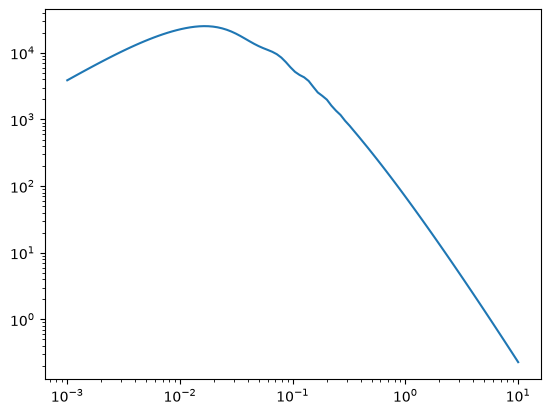

In [36]:
cosmo = Cosmology.from_preset("planck18")

power = LinearMatterPowSpec(transfer_kind="symbolic_pofk", 
                            growth_kind="symbolic_pofk", cosmology=cosmo)


k_ = jnp.logspace(-3, 1, 100)
pk_ = power.pk(k_)

plt.plot(k_, pk_)
plt.yscale("log")
plt.xscale("log")

In [37]:
delta = grf.sample_from_seed(1, box, pk_fn=power)

In [ ]:
delta.

PaintResult(fig=<Figure size 1000x500 with 4 Axes>, ax=<Axes: xlabel='$x$', ylabel='$y$'>, mappable=<matplotlib.image.AxesImage object at 0x73f190633800>)

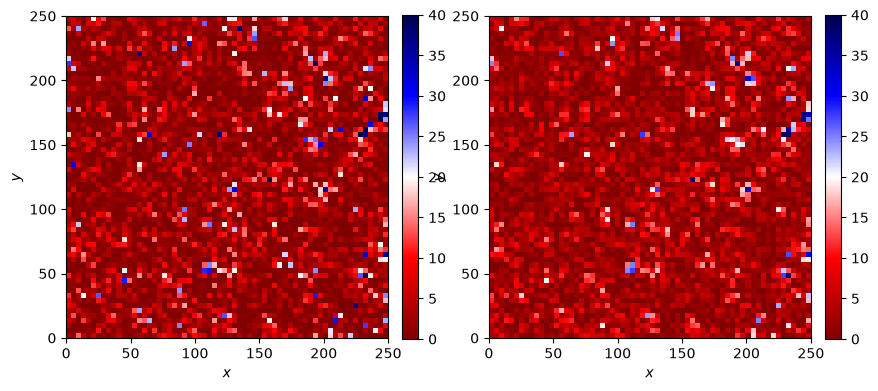

In [38]:
d2 = delta.product(delta, dealias=False, return_hat=False)
d2_dealias = delta.product(delta, N_iso=(box.N, box.N), dealias=True, return_hat=False)

fig, axs = plt.subplots(1, 2, figsize=(10,5))

d2.paint(ax=axs[0], cmap="seismic_r", vmin=0, vmax=40)
d2_dealias.paint(ax=axs[1], cmap="seismic_r", vmin=0, vmax=40)

PaintResult(fig=<Figure size 550x450 with 2 Axes>, ax=<Axes: xlabel='$x$', ylabel='$y$'>, mappable=<matplotlib.image.AxesImage object at 0x73f1983b04d0>)

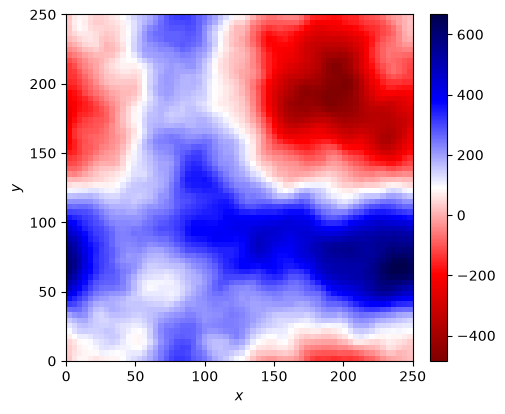

In [25]:
delta.inv_laplacian().paint(cmap="seismic_r")